In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Load the Superstore Data ---
import kagglehub
path = kagglehub.dataset_download("aditisaxena20/superstore-sales-dataset")
df = pd.read_csv(path + '\\SuperStore_Orders.csv', encoding='latin-1')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')  # Ensure sales is numeric
df = df.dropna(subset=['sales'])  # Drop rows where sales is NaN

In [2]:
# --- 2. Data Preprocessing and EDA ---
# Let's focus on a few categorical features and a numerical target
categorical_features = ['region', 'category', 'segment', 'ship_mode']
numerical_target = 'sales'

print("Original Data Head:")
print(df.head())
print("\nData Info:")
df.info()

Original Data Head:
          order_id  order_date   ship_date       ship_mode    customer_name  \
0     AG-2011-2040  01-01-2011  06-01-2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   
2     HU-2011-1220  01-01-2011  05-01-2011    Second Class    Annie Thurman   
3  IT-2011-3647632  01-01-2011  05-01-2011    Second Class     Eugene Moren   
4    IN-2011-47883  01-01-2011  08-01-2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name  sales  quantity  \
0  Office Suppl

In [3]:
# Basic descriptive statistics for Sales by Region
print("\nSales statistics by Region:")
print(df.groupby('region')['sales'].describe())


Sales statistics by Region:
                  count        mean         std  min   25%    50%    75%  \
region                                                                     
Africa           4448.0  120.979092  169.593338  1.0  20.0   51.0  142.0   
Canada            375.0  134.170667  171.630877  4.0  25.0   57.0  162.5   
Caribbean        1643.0  153.037736  186.804586  3.0  32.0   74.0  199.5   
Central         10543.0  171.359006  206.272674  0.0  32.0   86.0  229.0   
Central Asia     1867.0  208.626674  228.944541  3.0  50.0  115.0  282.0   
EMEA             4891.0  117.677776  165.531433  1.0  19.0   50.0  140.0   
East             2705.0  135.486876  193.939589  1.0  17.0   48.0  165.0   
North            4520.0  174.899558  207.419138  3.0  39.0   88.0  224.0   
North Asia       2121.0  213.901933  229.743376  3.0  50.0  121.0  294.0   
Oceania          3238.0  193.138357  217.421699  3.0  43.0  102.5  261.0   
South            6340.0  162.634227  199.867409  1.0  31.0 

In [5]:
df.groupby('region')['sales'].sample()

15274    124.0
48951     46.0
33168    882.0
3831     193.0
20792     98.0
33961     19.0
13444     12.0
15011    135.0
40178    147.0
45927     31.0
38177     36.0
2263      35.0
21103    449.0
Name: sales, dtype: float64

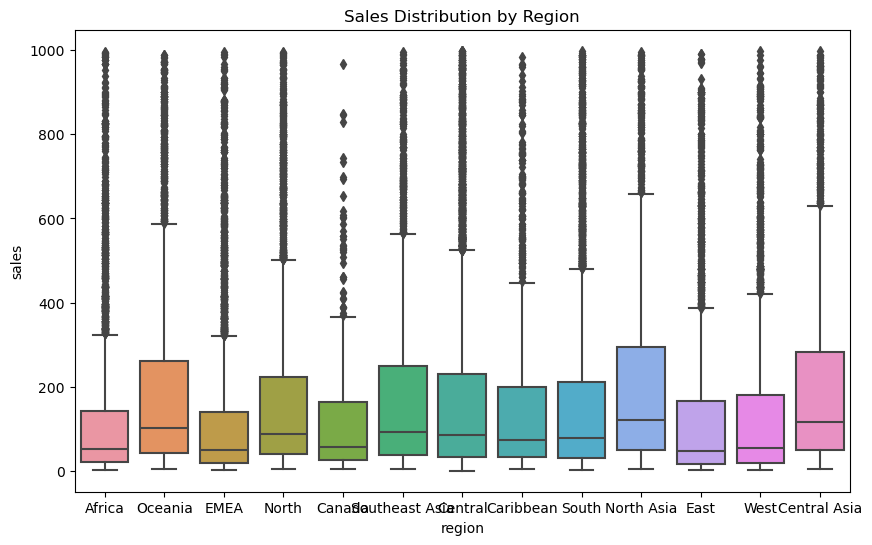

In [6]:
# Visualize Sales distribution across Regions (Box plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='sales', data=df)
plt.title('Sales Distribution by Region')
plt.show()

In [7]:
# --- 3. Apply One-Way ANOVA for Feature Selection ---
print("\n--- ANOVA for Feature Selection ---")

anova_results = {}
for feature in categorical_features:
    # Construct the OLS formula
    formula = f'{numerical_target} ~ C({feature})' # C() indicates categorical variable
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2) # Type 2 ANOVA is common

    anova_results[feature] = anova_table

    print(f"\nANOVA for {feature}:")
    print(anova_table)

    # Check p-value for the feature
    p_value = anova_table.loc[f'C({feature})', 'PR(>F)']
    if p_value < 0.05:
        print(f"  --> {feature} is statistically significant (p-value: {p_value:.4f})")
    else:
        print(f"  --> {feature} is NOT statistically significant (p-value: {p_value:.4f})")


--- ANOVA for Feature Selection ---

ANOVA for region:
                 sum_sq       df          F         PR(>F)
C(region)  3.667128e+07     12.0  76.986761  3.015192e-188
Residual   1.931011e+09  48647.0        NaN            NaN
  --> region is statistically significant (p-value: 0.0000)

ANOVA for category:
                   sum_sq       df            F  PR(>F)
C(category)  4.138668e+08      2.0  6480.020769     0.0
Residual     1.553816e+09  48657.0          NaN     NaN
  --> category is statistically significant (p-value: 0.0000)

ANOVA for segment:
                  sum_sq       df         F    PR(>F)
C(segment)  4.442477e+04      2.0  0.549282  0.577368
Residual    1.967638e+09  48657.0       NaN       NaN
  --> segment is NOT statistically significant (p-value: 0.5774)

ANOVA for ship_mode:
                    sum_sq       df         F    PR(>F)
C(ship_mode)  9.074644e+04      3.0  0.748014  0.523331
Residual      1.967592e+09  48656.0       NaN       NaN
  --> ship_mode is 

In [10]:
# Based on the ANOVA results, let's select features that are significant
significant_categorical_features = [
    feature for feature, result in anova_results.items()
    if result['PR(>F)'][f'C({feature})'] < 0.05
]

print(f"\nSignificant categorical features based on ANOVA (p < 0.05): {significant_categorical_features}")


Significant categorical features based on ANOVA (p < 0.05): ['region', 'category']


In [11]:
# --- 4. Build a Machine Learning Model (Example: Random Forest Regressor) ---
# Prepare data for ML model
# We'll use all initially considered categorical features and numerical ones
# For simplicity, let's also include 'quantity' and 'discount' as numerical features
# and 'profit' as it's highly correlated with sales.

features_for_ml = significant_categorical_features + ['quantity', 'discount', 'profit']
target = 'sales'

# One-hot encode the selected categorical features
df_encoded = pd.get_dummies(df[features_for_ml], columns=significant_categorical_features, drop_first=True)
df_encoded[target] = df[target]


missing_values = df_encoded.isnull().sum()
print("\nMissing Values in Encoded Data:")
print(missing_values[missing_values > 0])

print("\nEncoded Data Head for ML Model:")
print(df_encoded.head())

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining X shape: {X_train.shape}")
print(f"Testing X shape: {X_test.shape}")

# Initialize and train a Random Forest Regressor
print("\n--- Training Random Forest Regressor ---")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMachine Learning Model Evaluation (Random Forest Regressor):")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.4f}")


Missing Values in Encoded Data:
Series([], dtype: int64)

Encoded Data Head for ML Model:
   quantity  discount   profit  region_Canada  region_Caribbean  \
0         2       0.0  106.140          False             False   
1         3       0.1   36.036          False             False   
2         4       0.0   29.640          False             False   
3         3       0.5  -26.055          False             False   
4         5       0.1   37.770          False             False   

   region_Central  region_Central Asia  region_EMEA  region_East  \
0           False                False        False        False   
1           False                False        False        False   
2           False                False         True        False   
3           False                False        False        False   
4           False                False        False        False   

   region_North  region_North Asia  region_Oceania  region_South  \
0         False              

In [12]:
# --- Interpretation of ML Model Results ---
print("\n--- Further Interpretation ---")
# Feature Importance from Random Forest (if applicable)
if hasattr(model, 'feature_importances_'):
    feature_importances = pd.Series(model.feature_importances_, index=X.columns)
    sorted_importances = feature_importances.sort_values(ascending=False)
    print("\nFeature Importances from Random Forest for sales:")
    print(sorted_importances.head(10)) # Print top 10 important features


--- Further Interpretation ---

Feature Importances from Random Forest for sales:
profit                      0.681353
category_Office Supplies    0.101782
quantity                    0.075970
discount                    0.069817
category_Technology         0.010539
region_Central              0.008520
region_South                0.007677
region_West                 0.006599
region_East                 0.006121
region_North                0.005873
dtype: float64


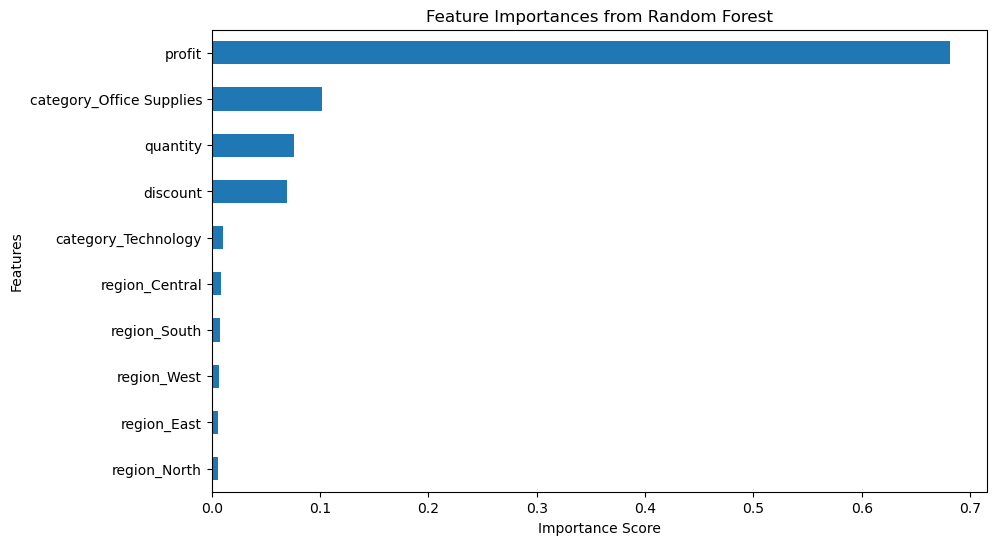

In [14]:
# Visualize Sales distribution across Regions (Box plot)
def visualize_feature_importances(importances):
    plt.figure(figsize=(10, 6))
    importances.sort_values(ascending=True).plot(kind='barh')
    plt.title('Feature Importances from Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()


visualize_feature_importances(sorted_importances.head(10))

# The 'Profit' feature will likely be highly important as it's directly related to Sales.
# The purpose of ANOVA here was to pre-screen categorical features.

In [20]:
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Using a classifier now
from sklearn.metrics import accuracy_score, classification_report

# Create a categorical target variable: 'profit_category'
# Let's categorize profit into 'Low_Profit' and 'High_Profit' based on the median
mean_profit = df['profit'].mean()
df['profit_category'] = df['profit'].apply(lambda x: 'High_Profit' if x >= mean_profit else 'Low_Profit')

print("Original Data Head with new profit_category:")
print(df[['profit', 'profit_category']].sample(10))

df['profit_category'].unique()  # Check unique values in profit_category

Original Data Head with new profit_category:
         profit profit_category
25235   84.5100     High_Profit
42806   -3.9032      Low_Profit
25843   10.4650      Low_Profit
1585     0.9900      Low_Profit
33888  173.5200     High_Profit
28594  -16.7720      Low_Profit
24425   77.0400     High_Profit
45132   15.6000     High_Profit
1848     7.2600      Low_Profit
39711 -164.7200      Low_Profit


array(['High_Profit', 'Low_Profit'], dtype=object)

In [22]:
# Features to test for association with profit_category
categorical_features = ['region', 'category', 'segment', 'ship_mode'] 

# --- 3. Apply Chi-squared Test for Feature Selection ---
print("\n--- Chi-squared Test for Feature Selection ---")

chi2_results = {}
for feature in categorical_features:
    # Create a contingency table
    contingency_table = pd.crosstab(df[feature], df['profit_category'])
    
    print(f"\nContingency Table for {feature} vs profit_category:")
    print(contingency_table)

    # Perform Chi-squared test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results[feature] = {'chi2': chi2, 'p_value': p_value, 'dof': dof}

    print(f"Chi-squared statistic for {feature}: {chi2:.4f}")
    print(f"P-value for {feature}: {p_value:.4f}")

    if p_value < 0.05:
        print(f"  --> {feature} is statistically significantly associated with profit_category (p-value: {p_value:.4f})")
    else:
        print(f"  --> {feature} is NOT statistically significantly associated with profit_category (p-value: {p_value:.4f})")



--- Chi-squared Test for Feature Selection ---

Contingency Table for region vs profit_category:
profit_category  High_Profit  Low_Profit
region                                  
Africa                  1561        2887
Canada                   164         211
Caribbean                583        1060
Central                 4339        6204
Central Asia            1031         836
EMEA                    1564        3327
East                     959        1746
North                   1979        2541
North Asia              1219         902
Oceania                 1261        1977
South                   2466        3874
Southeast Asia           785        2141
West                    1260        1783
Chi-squared statistic for region: 914.2259
P-value for region: 0.0000
  --> region is statistically significantly associated with profit_category (p-value: 0.0000)

Contingency Table for category vs profit_category:
profit_category  High_Profit  Low_Profit
category                      

In [23]:
# Based on the Chi-squared results, let's select features that are significant
significant_categorical_features_chi2 = [
    feature for feature, result in chi2_results.items()
    if result['p_value'] < 0.05
]

print(f"\nSignificant categorical features based on Chi-squared (p < 0.05) for categorical Profit: {significant_categorical_features_chi2}")


Significant categorical features based on Chi-squared (p < 0.05) for categorical Profit: ['region', 'category']


In [26]:
# --- 4. Build a Machine Learning Model (Example: Random Forest Classifier) ---
# Prepare data for ML model
# We'll use the significant categorical features and some numerical ones for classification

features_for_ml_chi2 = significant_categorical_features_chi2 + ['sales', 'quantity', 'discount']
target_ml = 'profit_category'

features_for_ml_chi2 = ['region', 'category', 'sales', 'quantity', 'discount']
df_encoded_chi2 = pd.get_dummies(df[features_for_ml_chi2], columns=significant_categorical_features_chi2, drop_first=True)
df_encoded_chi2[target_ml] = df[target_ml]

missing_values_chi2 = df_encoded_chi2.isnull().sum()
print("\nMissing Values in Encoded Data (Chi-squared influenced):")
print(missing_values_chi2[missing_values_chi2 > 0])

print("\nEncoded Data Head for ML Model (Chi-squared influenced):")
print(df_encoded_chi2.head())

X = df_encoded_chi2.drop(columns=[target_ml])
y = df_encoded_chi2[target_ml]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify for classification

print(f"\nTraining X shape: {X_train.shape}")
print(f"Testing X shape: {X_test.shape}")

# Initialize and train a Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
model_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_clf.fit(X_train, y_train)


Missing Values in Encoded Data (Chi-squared influenced):
Series([], dtype: int64)

Encoded Data Head for ML Model (Chi-squared influenced):
   sales  quantity  discount  region_Canada  region_Caribbean  region_Central  \
0  408.0         2       0.0          False             False           False   
1  120.0         3       0.1          False             False           False   
2   66.0         4       0.0          False             False           False   
3   45.0         3       0.5          False             False           False   
4  114.0         5       0.1          False             False           False   

   region_Central Asia  region_EMEA  region_East  region_North  \
0                False        False        False         False   
1                False        False        False         False   
2                False         True        False         False   
3                False        False        False          True   
4                False        False       

RandomForestClassifier(n_jobs=-1, random_state=42)

In [27]:
# Make predictions on the test set
y_pred_clf = model_clf.predict(X_test)

y_pred_clf

array(['Low_Profit', 'High_Profit', 'High_Profit', ..., 'High_Profit',
       'High_Profit', 'Low_Profit'], dtype=object)

In [28]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_clf)
class_report = classification_report(y_test, y_pred_clf)

print(f"\nMachine Learning Model Evaluation (Random Forest Classifier):")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(class_report)


Machine Learning Model Evaluation (Random Forest Classifier):
Accuracy: 0.8312

Classification Report:
              precision    recall  f1-score   support

 High_Profit       0.78      0.79      0.79      3834
  Low_Profit       0.86      0.86      0.86      5898

    accuracy                           0.83      9732
   macro avg       0.82      0.82      0.82      9732
weighted avg       0.83      0.83      0.83      9732




--- Further Interpretation (Chi-squared ML model) ---

Feature Importances from Random Forest Classifier for profit_category:
sales                       0.614721
discount                    0.221169
quantity                    0.076304
category_Office Supplies    0.027026
category_Technology         0.017870
region_West                 0.005267
region_Central              0.004675
region_East                 0.004459
region_Southeast Asia       0.004277
region_South                0.004020
dtype: float64


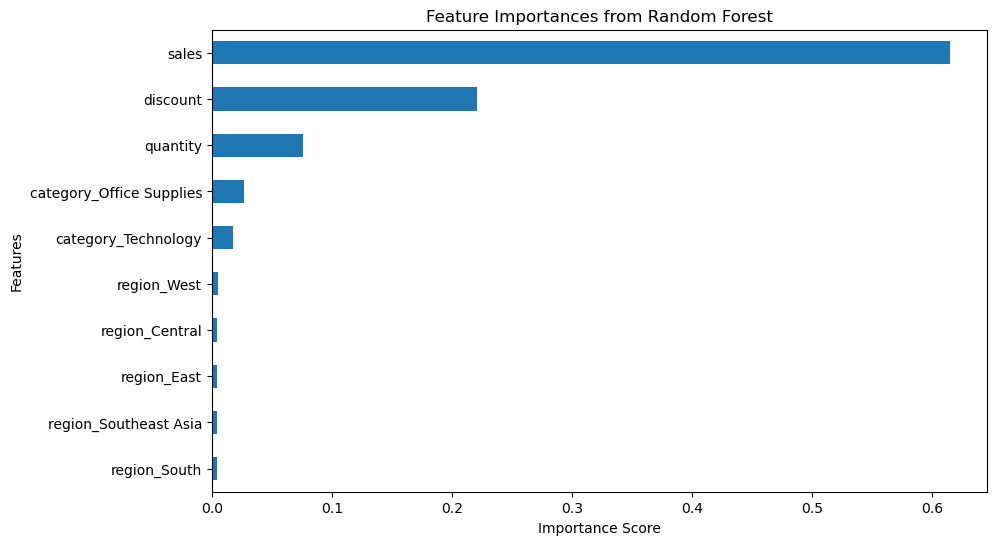

In [29]:
# --- Interpretation of ML Model Results ---
print("\n--- Further Interpretation (Chi-squared ML model) ---")
# Feature Importance from Random Forest (if applicable)
if hasattr(model_clf, 'feature_importances_'):
    feature_importances_clf = pd.Series(model_clf.feature_importances_, index=X.columns)
    sorted_importances_clf = feature_importances_clf.sort_values(ascending=False)
    print("\nFeature Importances from Random Forest Classifier for profit_category:")
    print(sorted_importances_clf.head(10))

visualize_feature_importances(sorted_importances_clf.head(10))

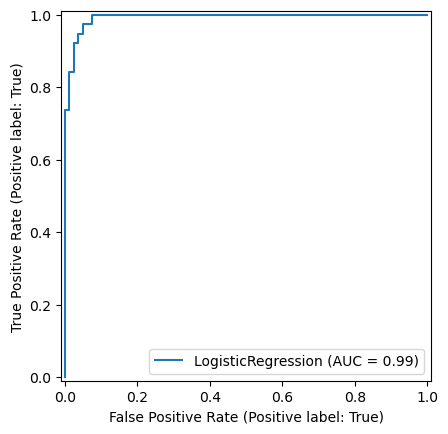

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
y = y == 2  # make binary
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=.8, random_state=42
)
clf = LogisticRegression(random_state=42, C=.01)
clf.fit(X_train, y_train)

clf_disp = RocCurveDisplay.from_estimator(clf, X_test, y_test)